In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [82]:
df = pd.read_csv("UpdatedResumeDataSet.csv")
df

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."
...,...,...
957,Testing,Computer Skills: â¢ Proficient in MS office (...
958,Testing,â Willingness to accept the challenges. â ...
959,Testing,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne..."
960,Testing,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...


In [79]:
df.Category.value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64

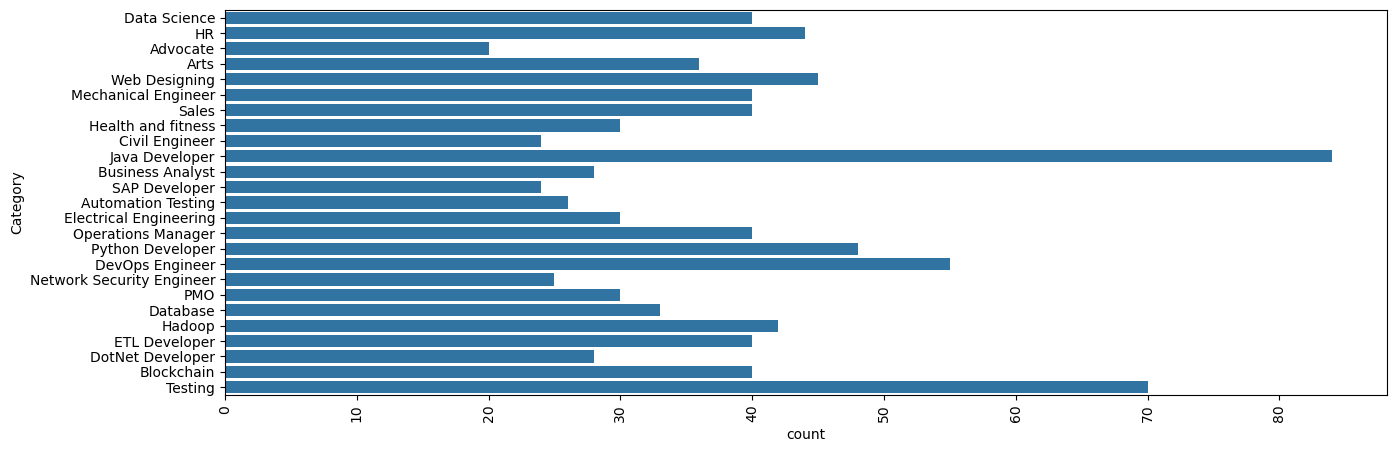

In [80]:
plt.figure(figsize=(15,5))
sns.countplot(df['Category']) 
plt.xticks(rotation=90)
plt.show()

In [16]:
d = list(df['Category'].unique())
d

['Data Science',
 'HR',
 'Advocate',
 'Arts',
 'Web Designing',
 'Mechanical Engineer',
 'Sales',
 'Health and fitness',
 'Civil Engineer',
 'Java Developer',
 'Business Analyst',
 'SAP Developer',
 'Automation Testing',
 'Electrical Engineering',
 'Operations Manager',
 'Python Developer',
 'DevOps Engineer',
 'Network Security Engineer',
 'PMO',
 'Database',
 'Hadoop',
 'ETL Developer',
 'DotNet Developer',
 'Blockchain',
 'Testing']

In [17]:
df['Category'].nunique()

25

In [18]:
df['Category'].value_counts().values

array([84, 70, 55, 48, 45, 44, 42, 40, 40, 40, 40, 40, 40, 36, 33, 30, 30,
       30, 28, 28, 26, 25, 24, 24, 20])

In [19]:
# category_mapping={}
# for i in range(len(d)):
#     # print(i,'........',d[i])
#     category_mapping[d[i]]=i

# print(category_mapping)

In [20]:
# df['Category_Encode'] = df['Category'].replace({'Data Science': 0, 'HR': 1, 'Advocate': 2, 'Arts': 3, 'Web Designing': 4, 'Mechanical Engineer': 5, 'Sales': 6, 'Health and fitness': 7, 'Civil Engineer': 8, 'Java Developer': 9, 'Business Analyst': 10, 'SAP Developer': 11, 'Automation Testing': 12, 'Electrical Engineering': 13, 'Operations Manager': 14, 'Python Developer': 15, 'DevOps Engineer': 16, 'Network Security Engineer': 17, 'PMO': 18, 'Database': 19, 'Hadoop': 20, 'ETL Developer': 21, 'DotNet Developer': 22, 'Blockchain': 23, 'Testing': 24})
# df

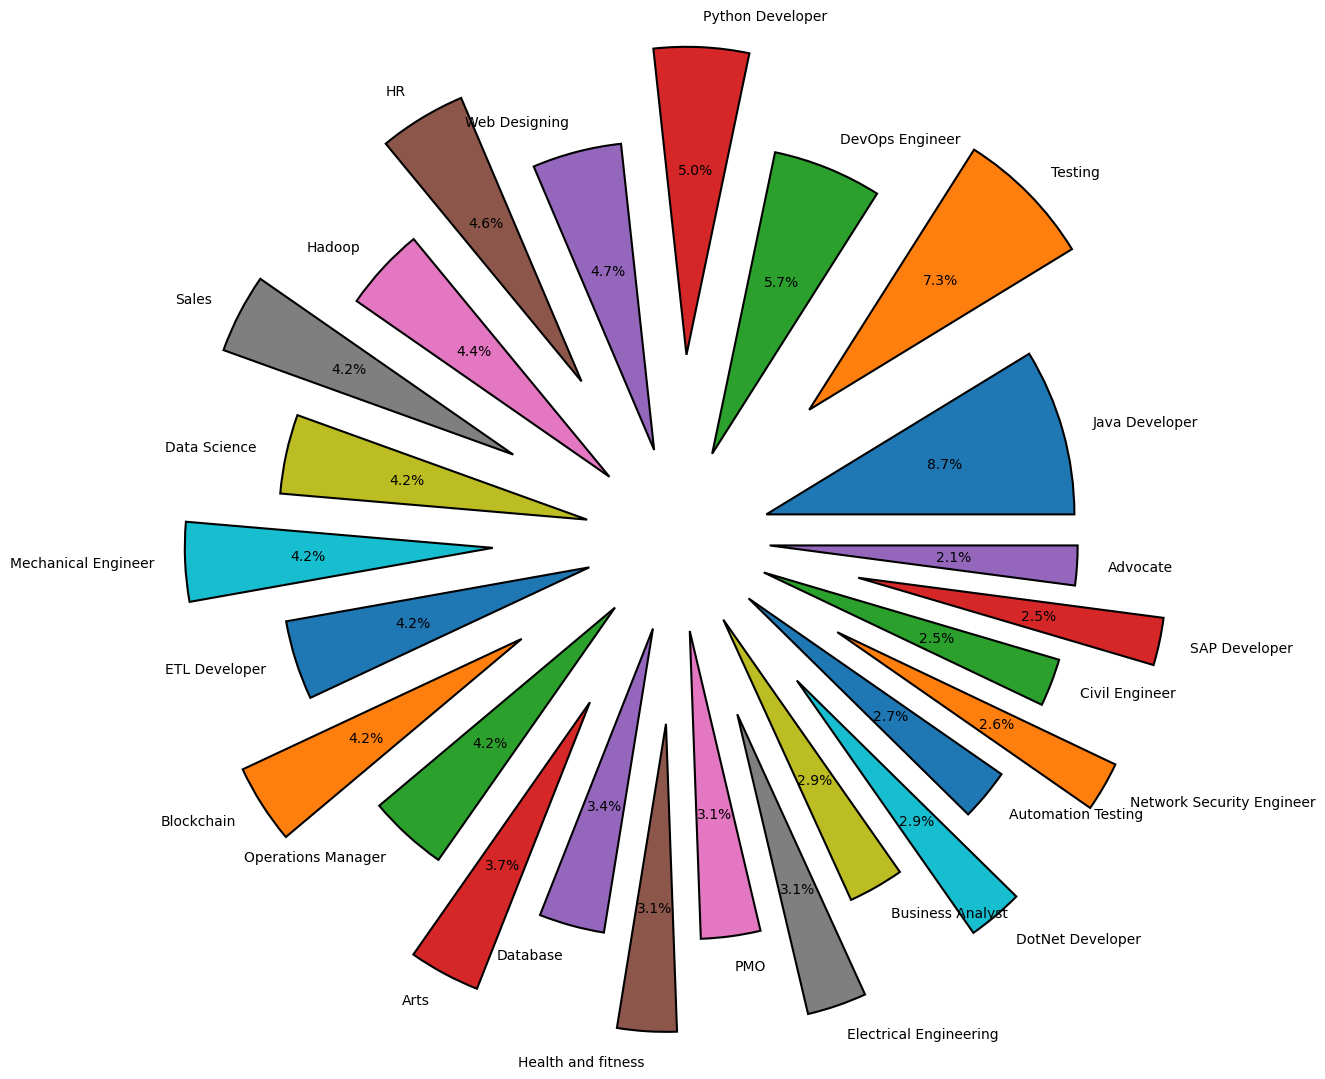

In [62]:
plt.figure(figsize=(15,10))
e=[0.3 if i%2==0 else 0.6 for i in range(25)]
wp = {'linewidth':1.5, "edgecolor":'black'}
plt.pie(df['Category'].value_counts().values,labels=df['Category'].value_counts().index,wedgeprops=wp,autopct='%0.1f%%',explode=e);

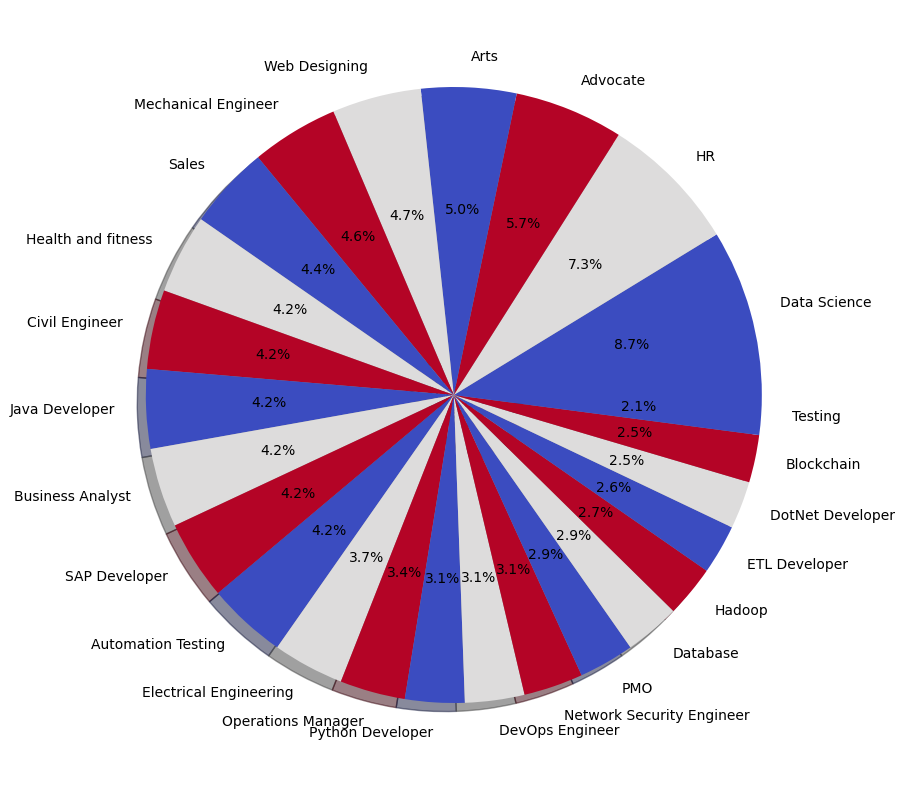

In [119]:
counts = df['Category'].value_counts()
labels = df['Category'].unique()
plt.figure(figsize=(15,10))

plt.pie(counts,labels=labels,autopct='%1.1f%%',shadow=True, colors=plt.cm.coolwarm(np.linspace(0,1,3)))
plt.show()

### Exploring Resume

In [29]:
df.Category[0]

'Data Science'

In [60]:
# df.Resume[0]

### Balance Classes (Categories)

In [31]:
df['Category'].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64

In [21]:
df.shape

(962, 2)

In [39]:
# Check the original category distribution
print("Original Category Distribution:")
print(df['Category'].value_counts())
print(df.shape)

# Get the largest category size (i.e., the category with the maximum number of entries)
max_size = df['Category'].value_counts().max()

# Perform oversampling
balanced_df = df.groupby('Category').apply(lambda x: x.sample(max_size, replace=True)).reset_index(drop=True)
print('length of balanced_df',balanced_df)

# Shuffle the dataset to avoid any order bias
df = balanced_df.sample(frac=1).reset_index(drop=True)

# Check the balanced category distribution
print("\nBalanced Category Distribution (After Oversampling):")
print(df['Category'].value_counts())
print(df.shape)

Original Category Distribution:
Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64
(962, 2)
length of balanced_df            Category                                             Resume
0          Advocate  Skills Leg

### Text Pre processing:
- 1 URLs,
- 2 hashtags,
- 3 mentions,
- 4 special letters,
- 5 punctuations:

In [33]:
df.shape

(2100, 3)

In [125]:
# for i in df['Resume'].head():
#     if 'RT' in i or 'cc' in i:
#         print(i)
#         print(i.replace('cc','****************************************************************************'))

In [83]:
import re
def cleanResume(txt):
    cleanText = re.sub('http\S+\s', ' ', txt) # removing url
    cleanText = re.sub('RT|cc', ' ', cleanText)
    cleanText = re.sub('#\S+\s', ' ', cleanText)
    cleanText = re.sub('@\S+', '  ', cleanText)  
    cleanText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', cleanText)
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText) 
    cleanText = re.sub('\s+', ' ', cleanText)
    return cleanText

In [64]:
cleanResume("by %%@@ * %  %farooqahmed portal look like this http://samplelink and reach me at @mailbox.net")

'by farooqahmed portal look like this and reach me at '

In [84]:
df['Resume'] = df['Resume'].apply(lambda x: cleanResume(x))

In [67]:
# df['Resume'][0]

### words into categorical values

In [85]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [70]:
c=df['Category'].unique()
c

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object)

In [39]:
# a = ['Python Developer', 'DotNet Developer', 'Sales',
#        'Mechanical Engineer', 'Testing', 'DevOps Engineer',
#        'ETL Developer', 'Database', 'Network Security Engineer', 'Hadoop',
#        'Java Developer', 'Civil Engineer', 'Electrical Engineering',
#        'SAP Developer', 'Advocate', 'Business Analyst',
#        'Automation Testing', 'PMO', 'Operations Manager', 'Arts',
#        'Web Designing', 'Data Science', 'HR', 'Blockchain',
#        'Health and fitness']

In [40]:
# le.fit_transform(df['Category'])

In [87]:
df

,Category,Resume
0,Data Science,Skills Programming Languages Python pandas num...
1,Data Science,Education Details May 2013 to May 2017 B E UIT...
2,Data Science,Areas of Interest Deep Learning Control System...
3,Data Science,Skills R Python SAP HANA Tableau SAP HANA SQL ...
4,Data Science,Education Details MCA YMCAUST Faridabad Haryan...
...,...,...
957,Testing,Computer Skills Proficient in MS office Word B...
958,Testing,Willingness to a ept the challenges Positive ...
959,Testing,PERSONAL SKILLS Quick learner Eagerness to lea...
960,Testing,COMPUTER SKILLS SOFTWARE KNOWLEDGE MS Power Po...


In [88]:
le.fit(df['Category'])
df['Category_Encode'] = le.transform(df['Category'])

In [89]:
df

,Category,Resume,Category_Encode
0,Data Science,Skills Programming Languages Python pandas num...,6
1,Data Science,Education Details May 2013 to May 2017 B E UIT...,6
2,Data Science,Areas of Interest Deep Learning Control System...,6
3,Data Science,Skills R Python SAP HANA Tableau SAP HANA SQL ...,6
4,Data Science,Education Details MCA YMCAUST Faridabad Haryan...,6
...,...,...,...
957,Testing,Computer Skills Proficient in MS office Word B...,23
958,Testing,Willingness to a ept the challenges Positive ...,23
959,Testing,PERSONAL SKILLS Quick learner Eagerness to lea...,23
960,Testing,COMPUTER SKILLS SOFTWARE KNOWLEDGE MS Power Po...,23


In [74]:
l = df.Category_Encode.unique()
l

array([ 6, 12,  0,  1, 24, 16, 22, 14,  5, 15,  4, 21,  2, 11, 18, 20,  8,
       17, 19,  7, 13, 10,  9,  3, 23])

In [43]:
# len(l)

In [44]:
# category_mapping={}

# for i,j in zip(list(c),list(l)):
#     category_mapping[j]=i
#     # print(i,'..........',j)

# print(category_mapping)

In [45]:
# category_mapping ={np.int64(2): 'Automation Testing', np.int64(19): 'PMO', np.int64(0): 'Advocate', np.int64(16): 'Mechanical Engineer', np.int64(22): 'Sales', np.int64(11): 'Electrical Engineering', np.int64(7): 'Database', np.int64(9): 'DotNet Developer', np.int64(20): 'Python Developer', np.int64(24): 'Web Designing', np.int64(13): 'Hadoop', np.int64(21): 'SAP Developer', np.int64(3): 'Blockchain', np.int64(4): 'Business Analyst', np.int64(5): 'Civil Engineer', np.int64(12): 'HR', np.int64(8): 'DevOps Engineer', np.int64(6): 'Data Science', np.int64(17): 'Network Security Engineer', np.int64(1): 'Arts', np.int64(14): 'Health and fitness', np.int64(15): 'Java Developer', np.int64(10): 'ETL Developer', np.int64(23): 'Testing', np.int64(18): 'Operations Manager'}

# category_mapping

In [46]:
# len(category_mapping)


In [159]:
# # Map category ID to category name
# category_mapping = {
#     15: "Java Developer",
#     23: "Testing",
#     8: "DevOps Engineer",
#     20: "Python Developer",
#     24: "Web Designing",
#     12: "HR",
#     13: "Hadoop",
#     3: "Blockchain",
#     10: "ETL Developer",
#     18: "Operations Manager",
#     6: "Data Science",
#     22: "Sales",
#     16: "Mechanical Engineer",
#     1: "Arts",
#     7: "Database",
#     11: "Electrical Engineering",
#     14: "Health and fitness",
# 19: "PMO",
# 4: "Business Analyst",
# 9: "DotNet Developer",
# 2: "Automation Testing",
# 17: "Network Security Engineer",
# 21: "SAP Developer",
# 5: "Civil Engineer",
# 0: "Advocate",
# }

# # category name = category_mapping.get(prediction_id, "Unknown")

# # print("Predicted Category:", category_name)
# print()



### Vactorization

In [90]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english')

tfidf.fit(df['Resume'])
requredTaxt  = tfidf.transform(df['Resume'])

In [162]:
# requredTaxt

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 368978 stored elements and shape (2100, 7335)>

### Splitting

In [91]:
from sklearn.model_selection import train_test_split

In [92]:
X_train, X_test, y_train, y_test = train_test_split(requredTaxt, df['Category_Encode'], test_size=0.2, random_state=42)

In [93]:
X_train.shape

(769, 7351)

In [94]:
X_test.shape

(193, 7351)

### Now let’s train the model and print the classification report:

In [96]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# KNeighborsClassifier
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
y_pred_knn_train = knn_model.predict(X_train)

print("\nKNeighborsClassifier Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Accuracy: {accuracy_score(y_train, y_pred_knn_train):.4f}")





KNeighborsClassifier Results:
Accuracy: 0.9845
Accuracy: 0.9857


In [54]:
df['Category'].value_counts()

Category
Operations Manager           84
HR                           84
ETL Developer                84
Electrical Engineering       84
Java Developer               84
Data Science                 84
Advocate                     84
Health and fitness           84
PMO                          84
Database                     84
Mechanical Engineer          84
Blockchain                   84
Civil Engineer               84
Hadoop                       84
Web Designing                84
Testing                      84
DevOps Engineer              84
Business Analyst             84
Automation Testing           84
SAP Developer                84
Sales                        84
DotNet Developer             84
Python Developer             84
Network Security Engineer    84
Arts                         84
Name: count, dtype: int64

In [51]:
df['Category_Encode'].value_counts()

Category_Encode
0     84
16    84
8     84
6     84
12    84
19    84
7     84
23    84
17    84
4     84
22    84
1     84
5     84
21    84
24    84
14    84
15    84
18    84
10    84
3     84
20    84
13    84
11    84
2     84
9     84
Name: count, dtype: int64

### Prediction System

In [56]:
# Function to predict the category of a resume
def pred(input_resume):
    # Preprocess the input text (e.g., cleaning, etc.)
    cleaned_text = cleanResume(input_resume) 

    # Vectorize the cleaned text using the same TF-IDF vectorizer used during training
    vectorized_text = tfidf.transform([cleaned_text])
    
    # Convert sparse matrix to dense
    vectorized_text = vectorized_text.toarray()

    # Prediction
    predicted_category = knn_model.predict(vectorized_text)

    # get name of predicted category
    predicted_category_name = le.inverse_transform(predicted_category)

    return predicted_category_name[0]  # Return the category name

In [132]:
myresume = """I am a data scientist specializing in machine
learning, deep learning, and computer vision. With
a strong background in mathematics, statistics,
and programming, I am passionate about
uncovering hidden patterns and insights in data.
I have extensive experience in developing
predictive models, implementing deep learning
algorithms, and designing computer vision
systems. My technical skills include proficiency in
Python, Sklearn, TensorFlow, and PyTorch.
What sets me apart is my ability to effectively
communicate complex concepts to diverse
audiences. I excel in translating technical insights
into actionable recommendations that drive
informed decision-making.
If you're looking for a dedicated and versatile data
scientist to collaborate on impactful projects, I am
eager to contribute my expertise. Let's harness the
power of data together to unlock new possibilities
and shape a better future.
Contact & Sources
Email: 611noorsaeed@gmail.com
Github: https://github.com/611noorsaeed
Linkdin: https://www.linkedin.com/in/noor-saeed654a23263/
Blogs: https://medium.com/@611noorsaeed
Youtube: Artificial Intelligence
ABOUT ME
WORK EXPERIENCE
SKILLES
NOOR SAEED
LANGUAGES
English
Urdu
Hindi
I am a versatile data scientist with expertise in a wide
range of projects, including machine learning,
recommendation systems, deep learning, and computer
vision. Throughout my career, I have successfully
developed and deployed various machine learning models
to solve complex problems and drive data-driven
decision-making
Machine Learnine
Deep Learning
Computer Vision
Recommendation Systems
Data Visualization
Programming Languages (Python, SQL)
Data Preprocessing and Feature Engineering
Model Evaluation and Deployment
Statistical Analysis
Communication and Collaboration
"""

pred(myresume)

'Data Science'

In [133]:
myresume = """
Jane Smith is a certified personal trainer with over 5 years of experience in helping individuals achieve their fitness goals. Specializing in weight loss, strength training, and sports conditioning, Jane has developed personalized workout routines for clients of all ages and fitness levels. She has extensive knowledge in nutrition and exercise science, and uses this to create holistic health and fitness programs that are tailored to individual needs.

Jane holds a degree in Exercise Science and is a certified trainer through the National Academy of Sports Medicine (NASM). She has worked with athletes, seniors, and individuals with chronic health conditions, helping them improve their physical well-being and overall quality of life.

Her expertise includes:
- Weight Loss and Body Composition
- Strength Training and Resistance Exercises
- Cardio Conditioning
- Nutrition Coaching and Meal Planning
- Injury Prevention and Rehabilitation
- Functional Movement and Flexibility Training
- Group Fitness Classes

Certifications:
- Certified Personal Trainer, NASM
- CPR and First Aid Certified
- Yoga Instructor (200-Hour Certification)

Education:
BSc in Exercise Science, ABC University, 2014-2018

Work Experience:
- Personal Trainer at XYZ Fitness Gym (2018-Present)
- Fitness Coach at Wellness Center (2016-2018)

Languages:
- English (Fluent)
- Spanish (Conversational)
"""

# Now, test the model with the Health and Fitness-focused resume
pred(myresume)

'Health and fitness'

In [134]:
myresume = """
John Doe is an experienced Network Security Engineer with over 7 years of expertise in designing, implementing, and managing network security infrastructures. Specializing in safeguarding critical network systems, John has worked with various organizations to protect against cyber threats, data breaches, and unauthorized access. He is proficient in deploying firewalls, intrusion detection systems (IDS), VPNs, and network monitoring tools to ensure the integrity and security of networks.

John holds a degree in Computer Science and certifications in several cybersecurity domains, including Certified Information Systems Security Professional (CISSP), Certified Ethical Hacker (CEH), and Cisco Certified Network Associate (CCNA). He has extensive experience in troubleshooting and resolving network vulnerabilities, and has played a key role in conducting security audits and risk assessments.

Key Skills:
- Network Security Architecture
- Firewall Management and Configuration
- Intrusion Detection and Prevention Systems (IDS/IPS)
- Virtual Private Networks (VPNs)
- Security Audits and Risk Assessments
- Cybersecurity Incident Response
- Network Monitoring and Traffic Analysis
- Vulnerability Assessment and Penetration Testing
- Data Encryption and Secure Communications

Certifications:
- CISSP (Certified Information Systems Security Professional)
- CEH (Certified Ethical Hacker)
- CCNA (Cisco Certified Network Associate)
- CompTIA Security+

Education:
BSc in Computer Science, XYZ University, 2012-2016

Professional Experience:
- Network Security Engineer at ABC Corp (2016-Present)
- IT Security Specialist at DEF Solutions (2014-2016)

Languages:
- English (Fluent)
- French (Intermediate)
"""

# Now, test the model with the Network Security Engineer-focused resume
pred(myresume)

'Network Security Engineer'

In [135]:
myresume = """
Sarah Williams is a dedicated and skilled advocate with over 10 years of experience in providing legal representation to clients across various sectors, including criminal law, civil litigation, and family law. With a deep understanding of legal procedures and case law, Sarah has successfully handled numerous cases in the courtroom, negotiating favorable settlements and providing expert legal advice to individuals and businesses.

She holds a law degree from XYZ University and is a licensed attorney, practicing law in multiple jurisdictions. Sarah is passionate about ensuring justice is served and strives to make legal processes more accessible to her clients. She is known for her excellent research and analytical skills, attention to detail, and commitment to upholding the law with integrity.

Key Skills:
- Criminal Law
- Civil Litigation
- Family Law
- Contract Law
- Legal Research and Writing
- Courtroom Advocacy
- Legal Counseling and Advice
- Client Relationship Management
- Legal Compliance and Regulations
- Negotiation and Settlement

Certifications and Licenses:
- Licensed Attorney at Law, XYZ State Bar
- Certification in Criminal Law, XYZ University

Education:
JD in Law, XYZ University, 2010-2013

Professional Experience:
- Senior Advocate at ABC Law Firm (2016-Present)
- Associate Advocate at DEF Legal Group (2013-2016)

Languages:
- English (Fluent)
- Spanish (Conversational)
"""

# Now, test the model with the Advocate-focused resume
pred(myresume)

'Advocate'

In [36]:
# Map category ID to category name
category_mapping = {
    15: "Java Developer",
    23: "Testing",
    8: "DevOps Engineer",
    20: "Python Developer",
    24: "Web Designing",
    12: "HR",
    13: "Hadoop",
    3: "Blockchain",
    10: "ETL Developer",
    18: "Operations Manager",
    6: "Data Science",
    22: "Sales",
    16: "Mechanical Engineer",
    1: "Arts",
    7: "Database",
    11: "Electrical Engineering",
    14: "Health and fitness",
19: "PMO",
4: "Business Analyst",
9: "DotNet Developer",
2: "Automation Testing",
17: "Network Security Engineer",
21: "SAP Developer",
5: "Civil Engineer",
0: "Advocate",
}
    
# category name = category_mapping.get(prediction_id, "Unknown")

# print("Predicted Category:", category_name)


In [62]:
# Map category ID to category name
category_mapping = {'Data Science': 0,
 'HR': 1,
 'Advocate': 2,
 'Arts': 3,
 'Web Designing': 4,
 'Mechanical Engineer': 5,
 'Sales': 6,
 'Health and fitness': 7,
 'Civil Engineer': 8,
 'Java Developer': 9,
 'Business Analyst': 10,
 'SAP Developer': 11,
 'Automation Testing': 12,
 'Electrical Engineering': 13,
 'Operations Manager': 14,
 'Python Developer': 15,
 'DevOps Engineer': 16,
 'Network Security Engineer': 17,
 'PMO': 18,
 'Database': 19,
 'Hadoop': 20,
 'ETL Developer': 21,
 'DotNet Developer': 22,
 'Blockchain': 23,
 'Testing': 24}

# category name = category_mapping.get(prediction_id, "Unknown")

# print("Predicted Category:", category_name)
print()



In [61]:
category_mapping

{'Data Science': 0,
 'HR': 1,
 'Advocate': 2,
 'Arts': 3,
 'Web Designing': 4,
 'Mechanical Engineer': 5,
 'Sales': 6,
 'Health and fitness': 7,
 'Civil Engineer': 8,
 'Java Developer': 9,
 'Business Analyst': 10,
 'SAP Developer': 11,
 'Automation Testing': 12,
 'Electrical Engineering': 13,
 'Operations Manager': 14,
 'Python Developer': 15,
 'DevOps Engineer': 16,
 'Network Security Engineer': 17,
 'PMO': 18,
 'Database': 19,
 'Hadoop': 20,
 'ETL Developer': 21,
 'DotNet Developer': 22,
 'Blockchain': 23,
 'Testing': 24}

In [97]:
import pickle
pickle.dump(tfidf,open('tfidf.pkl','wb'))
pickle.dump(knn_model, open('clf.pkl', 'wb'))
pickle.dump(le, open("encoder.pkl",'wb'))

In [ ]:
clf = pickle.load('clf.pkl','rb')

cleaned_resume = cleanResume(myresume)

input_features = tfidf.transform(cleaned_resume)

prediction_id = clf.predict(input_features)
